In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pima = pd.read_csv('diabetes.csv')

print(f"Shape: {pima.shape}")
print(f"\nColumns:\n{pima.columns.tolist()}")
print(f"\nTarget distribution:\n{pima['Outcome'].value_counts()}")
print(f"\nClass balance (%):\n{pima['Outcome'].value_counts(normalize=True) * 100}")
print(f"\nMissing values: {pima.isnull().sum().sum()} total")
print(f"\nFirst 5 rows:\n{pima.head()}")
print(f"\nBasic statistics:\n{pima.describe().round(2)}")

Shape: (768, 9)

Columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Target distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Class balance (%):
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

Missing values: 0 total

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21   

Zero counts before replacement:
  Glucose: 5 zeros
  BloodPressure: 35 zeros
  SkinThickness: 227 zeros
  Insulin: 374 zeros
  BMI: 11 zeros

Zero counts after replacement:
  Glucose: 0 zeros
  BloodPressure: 0 zeros
  SkinThickness: 0 zeros
  Insulin: 0 zeros
  BMI: 0 zeros

Features shape: (768, 8)
Target shape:   (768,)


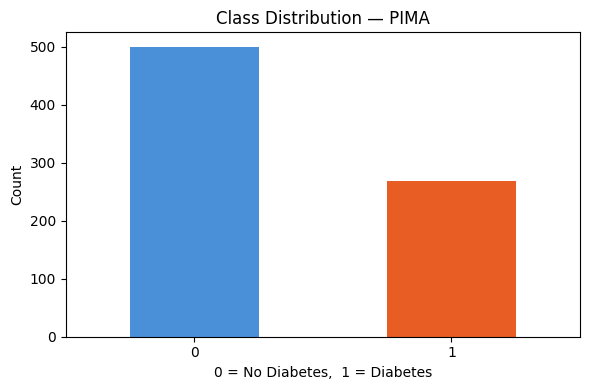


Features scaled using StandardScaler.

Applying SMOTE...
Before SMOTE — 0: 500,  1: 268
After  SMOTE — 0: 500,  1: 500

Train size: 800
Test size:  200


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Handle invalid zero values
# In PIMA, these columns cannot biologically be zero
# They represent missing values recorded as 0
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness',
                   'Insulin', 'BMI']

print("Zero counts before replacement:")
for col in cols_with_zeros:
    print(f"  {col}: {(pima[col] == 0).sum()} zeros")

pima[cols_with_zeros] = pima[cols_with_zeros].replace(0, np.nan)
pima.fillna(pima.median(), inplace=True)

print("\nZero counts after replacement:")
for col in cols_with_zeros:
    print(f"  {col}: {(pima[col] == 0).sum()} zeros")

# Separate features and target
X_pima = pima.drop('Outcome', axis=1)
y_pima = pima['Outcome']

print(f"\nFeatures shape: {X_pima.shape}")
print(f"Target shape:   {y_pima.shape}")

# Visualize class imbalance
plt.figure(figsize=(6, 4))
pima['Outcome'].value_counts().plot(
    kind='bar', color=['#4A90D9', '#E85D24'])
plt.title('Class Distribution — PIMA')
plt.xlabel('0 = No Diabetes,  1 = Diabetes')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pima)
print("\nFeatures scaled using StandardScaler.")

# Apply SMOTE to fix class imbalance
print("\nApplying SMOTE...")
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_scaled, y_pima)

print(f"Before SMOTE — 0: {sum(y_pima==0)},  1: {sum(y_pima==1)}")
print(f"After  SMOTE — 0: {sum(y_resampled==0)},  1: {sum(y_resampled==1)}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

print(f"\nTrain size: {X_train.shape[0]}")
print(f"Test size:  {X_test.shape[0]}")


Training Logistic Regression...

Logistic Regression:
              precision    recall  f1-score   support

           0       0.73      0.75      0.74       100
           1       0.74      0.72      0.73       100

    accuracy                           0.73       200
   macro avg       0.74      0.73      0.73       200
weighted avg       0.74      0.73      0.73       200

ROC-AUC: 0.8316

Training Random Forest...

Random Forest:
              precision    recall  f1-score   support

           0       0.86      0.79      0.82       100
           1       0.81      0.87      0.84       100

    accuracy                           0.83       200
   macro avg       0.83      0.83      0.83       200
weighted avg       0.83      0.83      0.83       200

ROC-AUC: 0.9100

Training XGBoost...

XGBoost:
              precision    recall  f1-score   support

           0       0.84      0.79      0.81       100
           1       0.80      0.85      0.83       100

    accuracy         

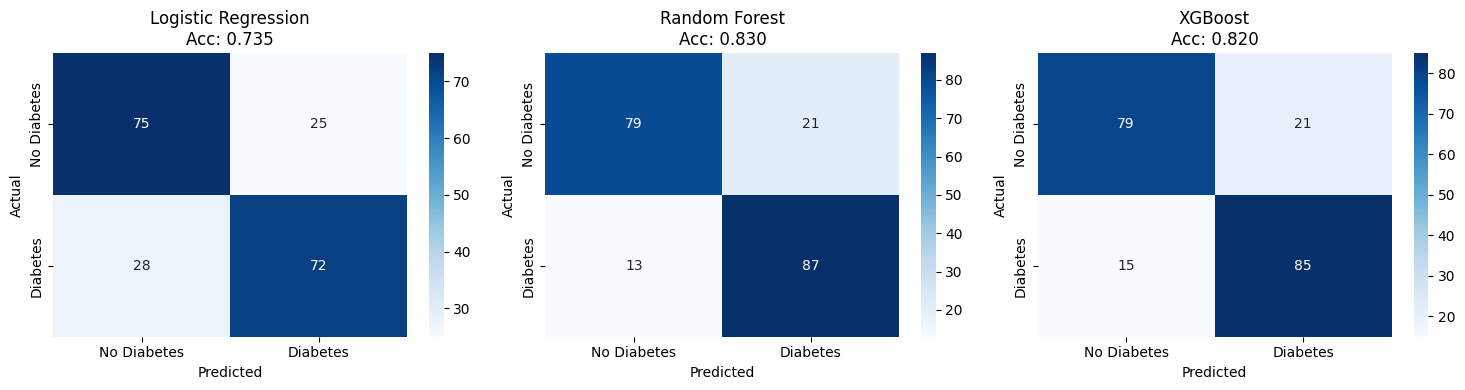

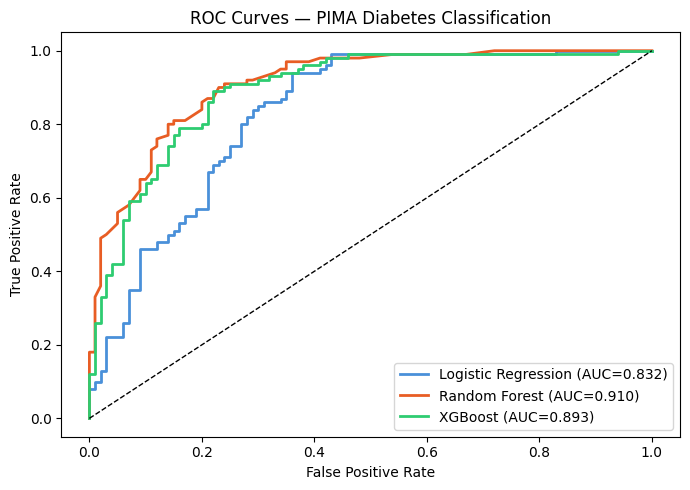


BEST MODEL SELECTED: Random Forest
  Recall (class 1):    0.8700
  F1 (class 1):        0.8365
  Accuracy:            0.8300
  ROC-AUC:             0.9100


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score, roc_curve)

# Define all three models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(use_label_encoder=False,
                                         eval_metric='logloss',
                                         random_state=42,
                                         n_jobs=-1)
}

# Train and evaluate all models
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)

    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    acc     = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    report  = classification_report(y_test, y_pred, output_dict=True)

    results[name] = {
        'model':         model,
        'accuracy':      acc,
        'roc_auc':       roc_auc,
        'f1_class1':     report['1']['f1-score'],
        'recall_1':      report['1']['recall'],
        'precision_1':   report['1']['precision'],
    }

    print(f"\n{name}:")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc:.4f}")

# Comparison summary table
summary_df = pd.DataFrame({
    name: {
        'Accuracy':            round(r['accuracy'], 4),
        'ROC-AUC':             round(r['roc_auc'], 4),
        'F1 (class 1)':        round(r['f1_class1'], 4),
        'Recall (class 1)':    round(r['recall_1'], 4),
        'Precision (class 1)': round(r['precision_1'], 4),
    }
    for name, r in results.items()
}).T

print("\nMODEL COMPARISON SUMMARY:")
print(summary_df.to_string())

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, r) in zip(axes, results.items()):
    y_pred = r['model'].predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Diabetes', 'Diabetes'],
                yticklabels=['No Diabetes', 'Diabetes'])
    ax.set_title(f'{name}\nAcc: {r["accuracy"]:.3f}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

# ROC Curves
plt.figure(figsize=(7, 5))
colors = ['#4A90D9', '#E85D24', '#2ECC71']
for (name, r), color in zip(results.items(), colors):
    y_pred_prob = r['model'].predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    plt.plot(fpr, tpr,
             label=f"{name} (AUC={r['roc_auc']:.3f})",
             color=color, lw=2)
plt.plot([0,1],[0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — PIMA Diabetes Classification')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Select best model
# Criteria: highest Recall for class 1 (diabetic)
# In healthcare, missing a diabetic patient is worse than a false alarm

best_name = max(results, key=lambda x: results[x]['recall_1'])
best_classifier = results[best_name]['model']

print(f"\nBEST MODEL SELECTED: {best_name}")
print(f"  Recall (class 1):    {results[best_name]['recall_1']:.4f}")
print(f"  F1 (class 1):        {results[best_name]['f1_class1']:.4f}")
print(f"  Accuracy:            {results[best_name]['accuracy']:.4f}")
print(f"  ROC-AUC:             {results[best_name]['roc_auc']:.4f}")

Risk scores generated for 768 PIMA patients.
Range: 0.0000 to 1.0000
Mean:  0.3845

Insurance dataset shape: (1338, 7)
Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

After encoding: ['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']

Bridge mapper trained.
  BMI coefficient: 0.022479
  Age coefficient: 0.009217
  Intercept:       -0.651433

Risk scores added to insurance dataset.
Range: 0.0000 to 0.9860
Mean:  0.3999


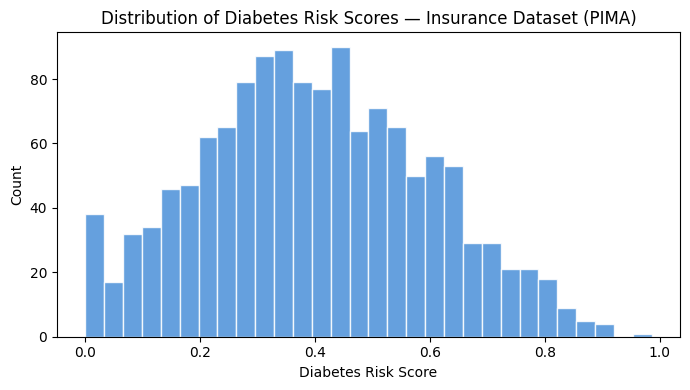

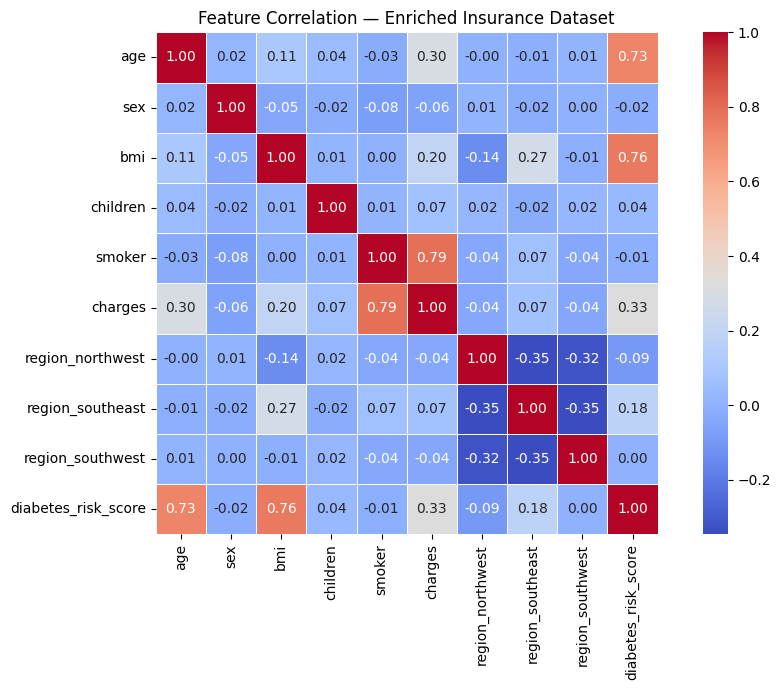


Saved: insurance_enriched_PIMA.csv
Final shape: (1338, 10)
Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest', 'diabetes_risk_score']

Verification — shape: (1338, 10)
   age     bmi  smoker  diabetes_risk_score      charges
0   19  27.900       1             0.150863  16884.92400
1   18  33.770       0             0.273599   1725.55230
2   28  33.000       0             0.348460   4449.46200
3   33  22.705       0             0.163120  21984.47061
4   32  28.880       0             0.292713   3866.85520
5   31  25.740       0             0.212911   3756.62160
6   46  33.440       0             0.524256   8240.58960
7   37  27.740       0             0.313171   7281.50560
8   37  29.830       0             0.360153   6406.41070
9   60  25.840       0             0.482451  28923.13692


In [ ]:
from sklearn.linear_model import LinearRegression as LinReg

# Generate risk scores for PIMA patients
# Use original scaled data (pre-SMOTE) for risk score generation
X_original_scaled = scaler.transform(X_pima)
pima_copy = pima.copy()
pima_copy['diabetes_risk_score'] = best_classifier.predict_proba(
    X_original_scaled)[:, 1]

print(f"Risk scores generated for {len(pima_copy)} PIMA patients.")
print(f"Range: {pima_copy['diabetes_risk_score'].min():.4f} "
      f"to {pima_copy['diabetes_risk_score'].max():.4f}")
print(f"Mean:  {pima_copy['diabetes_risk_score'].mean():.4f}")

# Load and encode insurance dataset
insurance = pd.read_csv('insurance.csv')

print(f"\nInsurance dataset shape: {insurance.shape}")
print(f"Columns: {insurance.columns.tolist()}")

insurance['sex']    = insurance['sex'].map({'male': 0, 'female': 1})
insurance['smoker'] = insurance['smoker'].map({'yes': 1, 'no': 0})
insurance = pd.get_dummies(insurance, columns=['region'], drop_first=True)

print(f"\nAfter encoding: {insurance.columns.tolist()}")

# Train bridge mapper (BMI + Age → risk score)
# PIMA has 'BMI' and 'Age' columns
# Insurance has 'bmi' and 'age' columns
# We map PIMA risk scores to insurance patients using shared features

mapper = LinReg()
mapper.fit(pima_copy[['BMI', 'Age']], pima_copy['diabetes_risk_score'])

print(f"\nBridge mapper trained.")
print(f"  BMI coefficient: {mapper.coef_[0]:.6f}")
print(f"  Age coefficient: {mapper.coef_[1]:.6f}")
print(f"  Intercept:       {mapper.intercept_:.6f}")

# Apply mapper to insurance dataset
insurance_bridge = insurance[['bmi', 'age']].copy()
insurance_bridge.columns = ['BMI', 'Age']  # match PIMA column names

insurance['diabetes_risk_score'] = mapper.predict(insurance_bridge)
insurance['diabetes_risk_score'] = insurance['diabetes_risk_score'].clip(0, 1)

print(f"\nRisk scores added to insurance dataset.")
print(f"Range: {insurance['diabetes_risk_score'].min():.4f} "
      f"to {insurance['diabetes_risk_score'].max():.4f}")
print(f"Mean:  {insurance['diabetes_risk_score'].mean():.4f}")

# Visualize risk score distribution
plt.figure(figsize=(7, 4))
plt.hist(insurance['diabetes_risk_score'], bins=30,
         color='#4A90D9', edgecolor='white', alpha=0.85)
plt.xlabel('Diabetes Risk Score')
plt.ylabel('Count')
plt.title('Distribution of Diabetes Risk Scores — Insurance Dataset (PIMA)')
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(insurance.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Feature Correlation — Enriched Insurance Dataset')
plt.tight_layout()
plt.show()

# Save enriched dataset
insurance.to_csv('insurance_enriched_PIMA.csv', index=False)
print(f"\nSaved: insurance_enriched_PIMA.csv")
print(f"Final shape: {insurance.shape}")
print(f"Columns: {insurance.columns.tolist()}")

# Verify saved file
df_check = pd.read_csv('insurance_enriched_PIMA.csv')
print(f"\nVerification — shape: {df_check.shape}")
print(df_check[['age', 'bmi', 'smoker',
                'diabetes_risk_score', 'charges']].head(10))

In [ ]:
insurance

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,diabetes_risk_score
0,19,1,27.900,0,1,16884.92400,False,False,True,0.150863
1,18,0,33.770,1,0,1725.55230,False,True,False,0.273599
2,28,0,33.000,3,0,4449.46200,False,True,False,0.348460
3,33,0,22.705,0,0,21984.47061,True,False,False,0.163120
4,32,0,28.880,0,0,3866.85520,True,False,False,0.292713
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,True,False,False,0.505600
1334,18,1,31.920,0,0,2205.98080,False,False,False,0.232012
1335,18,1,36.850,0,0,1629.83350,False,True,False,0.342835
1336,21,1,25.800,0,0,2007.94500,False,False,True,0.122090


Enriched Dataset Overview:
Shape:   (1338, 10)
Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest', 'diabetes_risk_score']

First 5 rows:
   age  sex     bmi  children  smoker      charges  region_northwest  \
0   19    1  27.900         0       1  16884.92400             False   
1   18    0  33.770         1       0   1725.55230             False   
2   28    0  33.000         3       0   4449.46200             False   
3   33    0  22.705         0       0  21984.47061              True   
4   32    0  28.880         0       0   3866.85520              True   

   region_southeast  region_southwest  diabetes_risk_score  
0             False              True             0.150863  
1              True             False             0.273599  
2              True             False             0.348460  
3             False             False             0.163120  
4             False             False             0.2

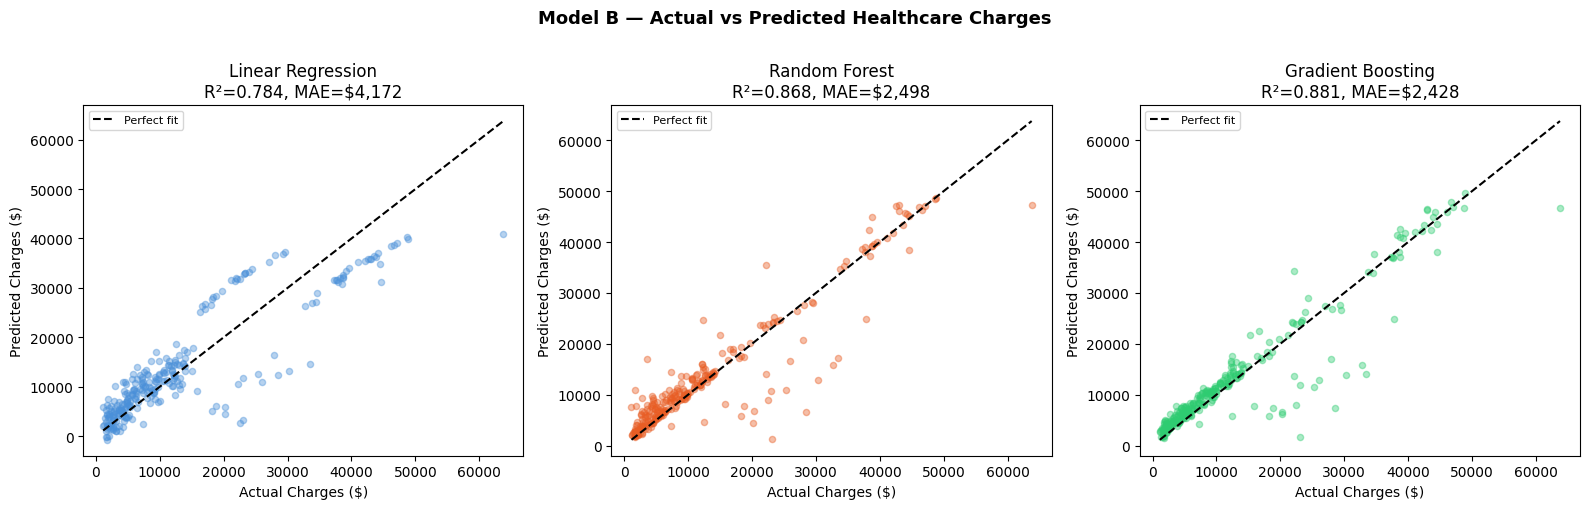

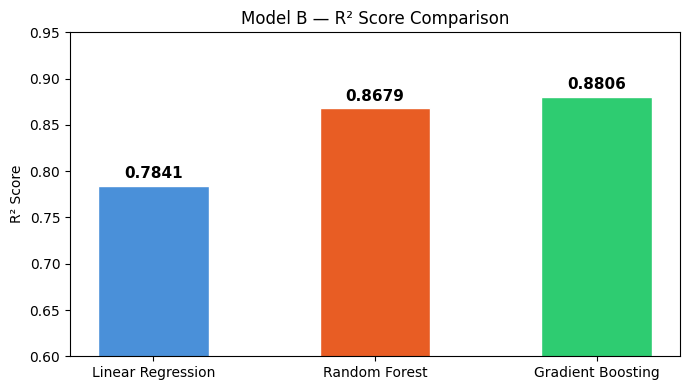

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

# Load enriched dataset
df = pd.read_csv('insurance_enriched_PIMA.csv')

print("Enriched Dataset Overview:")
print(f"Shape:   {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nMissing values: {df.isnull().sum().sum()}")

# Separate features and target
X = df.drop('charges', axis=1)
y = df['charges']

print(f"\nFeatures: {X.columns.tolist()}")
print(f"Target (charges) stats:")
print(y.describe().round(2))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"\nTrain size: {X_train.shape[0]}")
print(f"Test size:  {X_test.shape[0]}")

# Define all three regression models
reg_models = {
    'Linear Regression':   LinearRegression(),
    'Random Forest':       RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Train, evaluate, cross-validate all models
reg_results = {}

for name, model in reg_models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    mae    = mean_absolute_error(y_test, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    r2     = r2_score(y_test, y_pred)
    cv     = cross_val_score(model, X, y, cv=5, scoring='r2')

    reg_results[name] = {
        'model':       model,
        'MAE':         mae,
        'RMSE':        rmse,
        'R2':          r2,
        'CV_R2_mean':  cv.mean(),
        'CV_R2_std':   cv.std(),
        'y_pred':      y_pred
    }

    print(f"  R²:            {r2:.4f}  ({r2*100:.1f}% variance explained)")
    print(f"  MAE:           ${mae:,.2f}")
    print(f"  RMSE:          ${rmse:,.2f}")
    print(f"  CV R² (5-fold): {cv.mean():.4f} ± {cv.std():.4f}")

# Comparison summary table
reg_summary = pd.DataFrame({
    name: {
        'R² Score':     round(r['R2'], 4),
        'MAE ($)':      round(r['MAE'], 2),
        'RMSE ($)':     round(r['RMSE'], 2),
        'CV R² Mean':   round(r['CV_R2_mean'], 4),
        'CV R² Std':    round(r['CV_R2_std'], 4),
    }
    for name, r in reg_results.items()
}).T

print("\nMODEL B — COMPARISON SUMMARY:")
print(reg_summary.to_string())

# Select best regression model
best_reg_name = max(reg_results, key=lambda x: reg_results[x]['R2'])
best_regressor = reg_results[best_reg_name]['model']

print(f"\nBEST MODEL: {best_reg_name}")
print(f"  R²:   {reg_results[best_reg_name]['R2']:.4f}")
print(f"  MAE:  ${reg_results[best_reg_name]['MAE']:,.2f}")
print(f"  RMSE: ${reg_results[best_reg_name]['RMSE']:,.2f}")

# Actual vs Predicted plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#4A90D9', '#E85D24', '#2ECC71']

for ax, (name, r), color in zip(axes, reg_results.items(), colors):
    ax.scatter(y_test, r['y_pred'], alpha=0.4, color=color, s=20)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            'k--', lw=1.5, label='Perfect fit')
    ax.set_title(f"{name}\nR²={r['R2']:.3f}, MAE=${r['MAE']:,.0f}")
    ax.set_xlabel('Actual Charges ($)')
    ax.set_ylabel('Predicted Charges ($)')
    ax.legend(fontsize=8)

plt.suptitle('Model B — Actual vs Predicted Healthcare Charges',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# R² bar chart comparison
plt.figure(figsize=(7, 4))
names = list(reg_results.keys())
r2_scores = [r['R2'] for r in reg_results.values()]
bars = plt.bar(names, r2_scores,
               color=['#4A90D9', '#E85D24', '#2ECC71'],
               edgecolor='white', width=0.5)
for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{score:.4f}', ha='center', va='bottom',
             fontsize=11, fontweight='bold')
plt.ylim(0.6, 0.95)
plt.ylabel('R² Score')
plt.title('Model B — R² Score Comparison')
plt.tight_layout()
plt.show()

In [ ]:
import shap
shap.initjs()

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Re-create PIMA train-test split for Model A SHAP analysis
# This is required because X_test was overwritten by the insurance dataset's X_test
X_train_pima, X_test_pima_np, y_train_pima, y_test_pima = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

# Convert X_test_pima_np (numpy array) back to DataFrame for SHAP plots
# using the original PIMA feature names
X_test_pima_df = pd.DataFrame(X_test_pima_np, columns=X_pima.columns)

# PART A — SHAP for Model A (Diabetes Classification)

print("Applying SHAP to Model A (Diabetes Classification)...")

explainer_a = shap.TreeExplainer(best_classifier)
# Calculate SHAP values for Model A using the correct PIMA test data
shap_values_a = explainer_a.shap_values(X_test_pima_df)

# For Random Forest binary classification, shap_values can be a list of arrays
# (one for each class) or a single 3D array (n_samples, n_features, n_classes).
# We need the SHAP values for class 1 (diabetic).
if isinstance(shap_values_a, list):
    sv_a = shap_values_a[1]
elif isinstance(shap_values_a, np.ndarray) and shap_values_a.ndim == 3:
    sv_a = shap_values_a[:, :, 1] # Select SHAP values for class 1
else:
    # Fallback, assuming it's already a (n_samples, n_features) array for the positive class
    sv_a = shap_values_a

Applying SHAP to Model A (Diabetes Classification)...


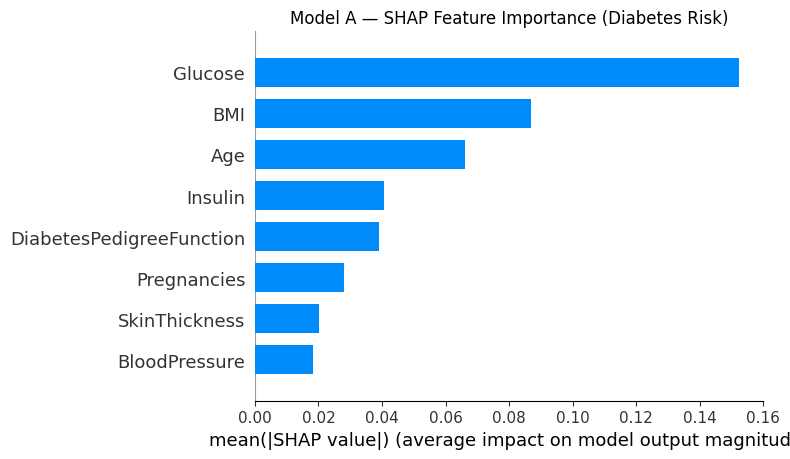

In [ ]:
# Global feature importance — Model A
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
shap.summary_plot(sv_a, X_test_pima_df,
                  feature_names=X_pima.columns.tolist(),
                  plot_type='bar',
                  show=False)
plt.title('Model A — SHAP Feature Importance (Diabetes Risk)')
plt.tight_layout()
plt.show()
plt.close()

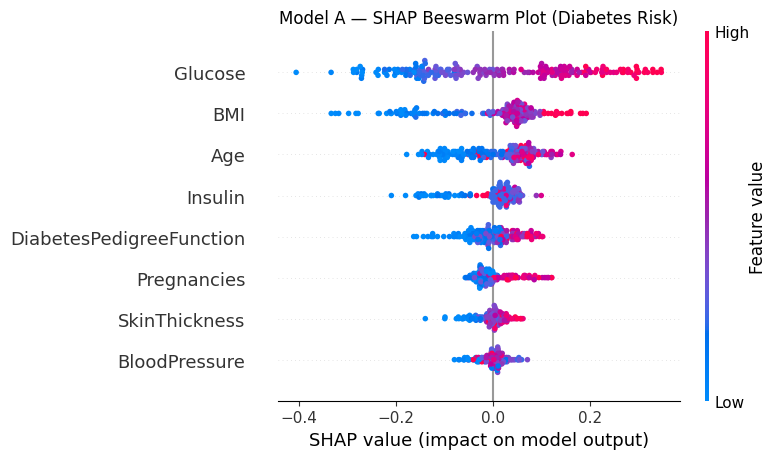

In [ ]:
# SHAP Beeswarm plot — Model A
plt.figure(figsize=(8, 5))
shap.summary_plot(sv_a, X_test_pima_df,
                  feature_names=X_pima.columns.tolist(),
                  show=False)
plt.title('Model A — SHAP Beeswarm Plot (Diabetes Risk)')
plt.tight_layout()
plt.show()
plt.close()

In [ ]:
# SHAP Force plot — individual patient (Model A)
print("\nIndividual Patient Explanation — Model A:")
print("Patient 0 features:", X_test_pima_df.iloc[0]) # Use the correct PIMA test DataFrame

base_value_a_scalar = explainer_a.expected_value[1]
if isinstance(base_value_a_scalar, np.ndarray):
    base_value_a_scalar = base_value_a_scalar.item() # Ensure it's a scalar

# Generate the force plot HTML but do not display inline
force_plot_html = shap.force_plot(
    base_value_a_scalar, # Use the explicitly scalar base value
    sv_a[0],
    X_test_pima_df.iloc[0], # Use the correct PIMA test DataFrame here
    feature_names=X_pima.columns.tolist(),
    show=False # Do not show as matplotlib plot
).html()

# Save the HTML to a file
with open('shap_force_plot_model_A_patient_0.html', 'w') as f:
    f.write(force_plot_html)
print("  -> SHAP Force Plot for Model A (Patient 0) saved to shap_force_plot_model_A_patient_0.html")


Individual Patient Explanation — Model A:
Patient 0 features: Pregnancies                 2.308385
Glucose                    -0.923177
BloodPressure              -0.827627
SkinThickness              -2.456685
Insulin                     1.283943
BMI                        -0.697626
DiabetesPedigreeFunction    1.402923
Age                         0.919529
Name: 0, dtype: float64
  -> SHAP Force Plot for Model A (Patient 0) saved to shap_force_plot_model_A_patient_0.html


In [ ]:
# SHAP feature importance values — Model A
import pandas as pd
import numpy as np
mean_shap_a = pd.Series(
    np.abs(sv_a).mean(axis=0),
    index=X_pima.columns # X_pima.columns has 8 features, sv_a will now match this if calculated correctly.
).sort_values(ascending=False)

print("\nModel A — Mean |SHAP| Feature Importance:")
for feat, val in mean_shap_a.items():
    pct = val / mean_shap_a.sum() * 100
    print(f"  {feat:<35} {val:.4f}  ({pct:.1f}%)")


Model A — Mean |SHAP| Feature Importance:
  Glucose                             0.1524  (33.7%)
  BMI                                 0.0869  (19.2%)
  Age                                 0.0663  (14.7%)
  Insulin                             0.0407  (9.0%)
  DiabetesPedigreeFunction            0.0389  (8.6%)
  Pregnancies                         0.0281  (6.2%)
  SkinThickness                       0.0201  (4.4%)
  BloodPressure                       0.0184  (4.1%)



Applying SHAP to Model B (Healthcare Cost Prediction)...


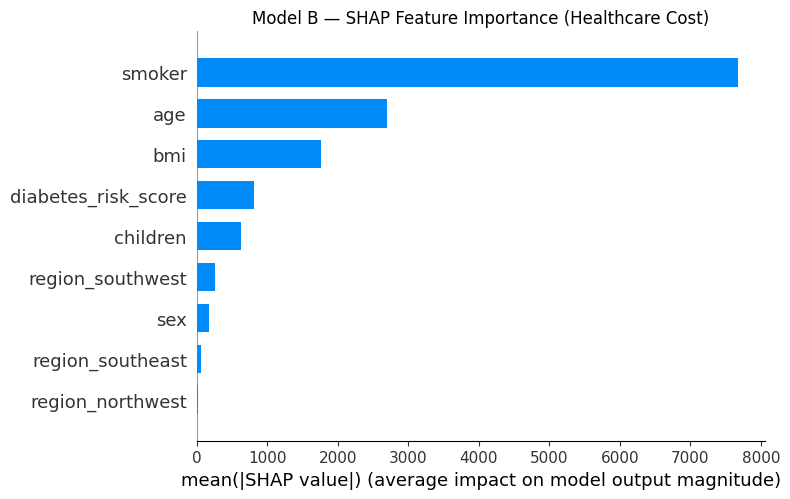

In [ ]:

# PART B — SHAP for Model B (Healthcare Cost Regression)

print("\nApplying SHAP to Model B (Healthcare Cost Prediction)...")

explainer_b = shap.TreeExplainer(best_regressor)
shap_values_b = explainer_b.shap_values(X_test)

# Global feature importance — Model B
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values_b, X_test,
                  feature_names=X.columns.tolist(),
                  plot_type='bar',
                  show=False)
plt.title('Model B — SHAP Feature Importance (Healthcare Cost)')
plt.tight_layout()
plt.show()
plt.close()

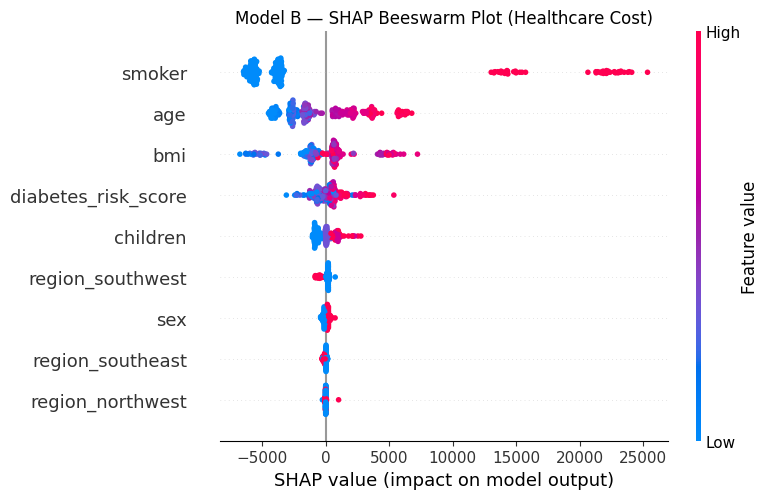

In [ ]:
# SHAP Beeswarm plot — Model B
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values_b, X_test,
                  feature_names=X.columns.tolist(),
                  show=False)
plt.title('Model B — SHAP Beeswarm Plot (Healthcare Cost)')
plt.tight_layout()
plt.show()
plt.close()

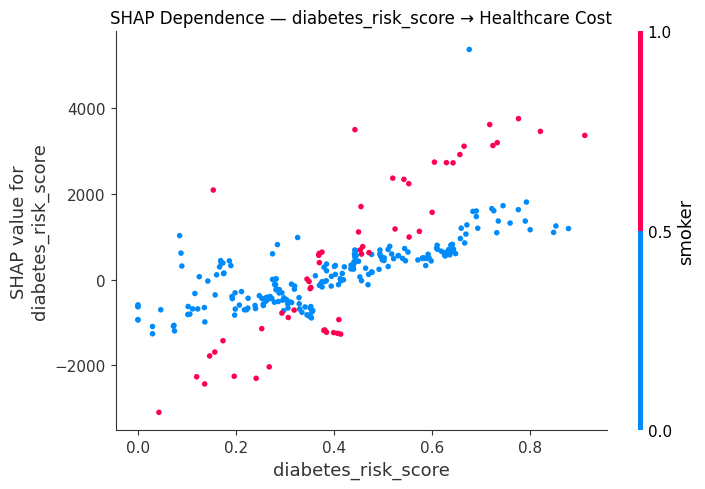


Model B — Mean |SHAP| Feature Importance:
  smoker                              7672.7886  (54.5%)
  age                                 2703.6008  (19.2%)
  bmi                                 1764.3803  (12.5%)
  diabetes_risk_score                 814.5448  (5.8%)
  children                            623.6092  (4.4%)
  region_southwest                    257.8714  (1.8%)
  sex                                 170.8021  (1.2%)
  region_southeast                    57.4035  (0.4%)
  region_northwest                    17.8814  (0.1%)

EXAMPLE PATIENT — FULL EXPLAINABLE REPORT

Patient features:
age                          45
sex                           1
bmi                      25.175
children                      2
smoker                        0
region_northwest          False
region_southeast          False
region_southwest          False
diabetes_risk_score    0.329247

Diabetes Risk Score: 0.329 → MODERATE RISK
Predicted Annual Healthcare Cost: $10,055.64

Top cost drivers (

In [ ]:
# Dependence plot for diabetes_risk_score
# This is your KEY research result — shows how risk score
# directly influences predicted healthcare charges
shap.dependence_plot(
    'diabetes_risk_score',
    shap_values_b,
    X_test,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title('SHAP Dependence — diabetes_risk_score → Healthcare Cost')
plt.tight_layout()
plt.show()

# SHAP feature importance values — Model B
mean_shap_b = pd.Series(
    np.abs(shap_values_b).mean(axis=0),
    index=X.columns
).sort_values(ascending=False)

print("\nModel B — Mean |SHAP| Feature Importance:")
for feat, val in mean_shap_b.items():
    pct = val / mean_shap_b.sum() * 100
    print(f"  {feat:<35} {val:.4f}  ({pct:.1f}%)")

# Example patient full report
print("\n"+"="*60)
print("EXAMPLE PATIENT — FULL EXPLAINABLE REPORT")
print("="*60)

patient_idx = 0
patient_features = X_test.iloc[patient_idx]
patient_risk_score = patient_features['diabetes_risk_score']
predicted_cost = best_regressor.predict(
    X_test.iloc[[patient_idx]])[0]

risk_label = "HIGH" if patient_risk_score >= 0.6 else \
             "MODERATE" if patient_risk_score >= 0.3 else "LOW"

print(f"\nPatient features:")
print(patient_features.to_string())
print(f"\nDiabetes Risk Score: {patient_risk_score:.3f} → {risk_label} RISK")
print(f"Predicted Annual Healthcare Cost: ${predicted_cost:,.2f}")

print("\nTop cost drivers (SHAP):")
patient_shap = pd.Series(
    shap_values_b[patient_idx],
    index=X.columns
).abs().sort_values(ascending=False)
for feat, val in patient_shap.head(5).items():
    direction = "↑ increases" if shap_values_b[
        patient_idx][X.columns.get_loc(feat)] > 0 else "↓ decreases"
    print(f"  {feat:<30} {direction} cost by ${abs(shap_values_b[patient_idx][X.columns.get_loc(feat)]):,.0f}")

In [ ]:
# FINAL RESULTS & PAPER COMPARISON

print("="*65)
print("FINAL RESULTS SUMMARY — COMPLETE FRAMEWORK")
print("="*65)

# ── Model A Final Results ─────────────────────────────────────
print("\n📌 MODEL A — Diabetes Classification (PIMA Dataset)")
print("-"*65)
print(f"{'Model':<25} {'Accuracy':>10} {'Recall':>10} "
      f"{'F1':>10} {'ROC-AUC':>10}")
print("-"*65)
for name, r in results.items():
    marker = " ★ BEST" if name == best_name else ""
    print(f"{name:<25} {r['accuracy']:>10.4f} "
          f"{r['recall_1']:>10.4f} "
          f"{r['f1_class1']:>10.4f} "
          f"{r['roc_auc']:>10.4f}{marker}")

# Model B Final Results
print("\n📌 MODEL B — Healthcare Cost Regression (Enriched Insurance)")
print("-"*65)
print(f"{'Model':<25} {'R²':>10} {'MAE ($)':>12} "
      f"{'RMSE ($)':>12} {'CV R²':>10}")
print("-"*65)
for name, r in reg_results.items():
    marker = " ★ BEST" if name == best_reg_name else ""
    print(f"{name:<25} {r['R2']:>10.4f} "
          f"{r['MAE']:>12,.2f} "
          f"{r['RMSE']:>12,.2f} "
          f"{r['CV_R2_mean']:>10.4f}{marker}")

# Comparison with existing papers
print("\n📌 COMPARISON WITH EXISTING PUBLISHED PAPERS")
print("-"*65)
print("Paper 1 — Patra et al. 2024 (JDAIP)")
print(f"  Their best (XGBoost):  R² = 0.8681, RMSE = $4,450")
print(f"  Our best ({best_reg_name}): "
      f"R² = {reg_results[best_reg_name]['R2']:.4f}, "
      f"RMSE = ${reg_results[best_reg_name]['RMSE']:,.2f}")
our_r2 = reg_results[best_reg_name]['R2']
if our_r2 > 0.8681:
    print(f"  ✅ Our R² is HIGHER by {(our_r2 - 0.8681):.4f}")
else:
    print(f"  📊 R² difference: {(our_r2 - 0.8681):.4f}")
print(f"  ✅ We add: SHAP explainability, diabetes_risk_score,")
print(f"     5-fold CV, dual prediction framework")

print("\nPaper 2 — Shen ICDSE 2025")
print(f"  Their best (XGBoost):  R² = 0.8800")
print(f"  Our best ({best_reg_name}): "
      f"R² = {reg_results[best_reg_name]['R2']:.4f}")
if our_r2 >= 0.88:
    print(f"  ✅ Our R² MATCHES or EXCEEDS their benchmark")
else:
    print(f"  📊 Our R² is comparable within {abs(our_r2-0.88):.4f}")
print(f"  ✅ We add: diabetes risk integration, dual framework,")
print(f"     clinically-grounded bridge feature (Framingham paradigm)")

# diabetes_risk_score contribution
print("\n📌 DIABETES_RISK_SCORE FEATURE CONTRIBUTION")
print("-"*65)
risk_importance = mean_shap_b.get('diabetes_risk_score', 0)
risk_pct = risk_importance / mean_shap_b.sum() * 100
rank = list(mean_shap_b.index).index('diabetes_risk_score') + 1
print(f"  SHAP importance:  {risk_importance:.4f}")
print(f"  % contribution:   {risk_pct:.1f}%")
print(f"  Rank among all features: #{rank} out of {len(X.columns)}")
print(f"  ✅ Ranks ahead of: "
      f"{', '.join(list(mean_shap_b.index)[rank:rank+3])}")

# Research contribution summary
print("\n📌 RESEARCH CONTRIBUTION SUMMARY")
print("-"*65)
print("  01. Dual Prediction Framework (risk + cost in one pipeline)")
print("  02. Novel clinical risk-score bridge (Framingham paradigm)")
print("  03. SHAP explainability across medical + financial features")
print("  04. Empirical PIMA vs BRFSS comparison — data-driven choice")
print("  05. Directly solves limitations of Patra 2024 & Shen 2025")
print("\n✅ FRAMEWORK COMPLETE")

FINAL RESULTS SUMMARY — COMPLETE FRAMEWORK

📌 MODEL A — Diabetes Classification (PIMA Dataset)
-----------------------------------------------------------------
Model                       Accuracy     Recall         F1    ROC-AUC
-----------------------------------------------------------------
Logistic Regression           0.7350     0.7200     0.7310     0.8316
Random Forest                 0.8300     0.8700     0.8365     0.9100 ★ BEST
XGBoost                       0.8200     0.8500     0.8252     0.8926

📌 MODEL B — Healthcare Cost Regression (Enriched Insurance)
-----------------------------------------------------------------
Model                             R²      MAE ($)     RMSE ($)      CV R²
-----------------------------------------------------------------
Linear Regression             0.7841     4,172.50     5,790.12     0.7465
Random Forest                 0.8679     2,498.27     4,527.84     0.8386
Gradient Boosting             0.8806     2,428.05     4,306.22     0.85

In [ ]:

import joblib
import os

os.makedirs('models', exist_ok=True)

joblib.dump(best_classifier, 'models/rf_classifier.pkl')
joblib.dump(best_regressor,  'models/gb_regressor.pkl')
joblib.dump(scaler,          'models/scaler.pkl')
joblib.dump(mapper,          'models/bridge_mapper.pkl')

print("✅ All models saved successfully!")
print("Files created:")
print("  models/rf_classifier.pkl   ← Random Forest (diabetes)")
print("  models/gb_regressor.pkl    ← Gradient Boosting (cost)")
print("  models/scaler.pkl          ← StandardScaler")
print("  models/bridge_mapper.pkl   ← Bridge Linear Regression")


✅ All models saved successfully!
Files created:
  models/rf_classifier.pkl   ← Random Forest (diabetes)
  models/gb_regressor.pkl    ← Gradient Boosting (cost)
  models/scaler.pkl          ← StandardScaler
  models/bridge_mapper.pkl   ← Bridge Linear Regression
